# NVDA Grid Strategy Backtest
`data_NVDA.csv` 全量数据（2022-04-18 → 2025-12-31）

## 1. 参数设置

In [1]:
SYMBOL      = 'NVDA'
START_DATE  = None   # None = 用 CSV 全部数据
END_DATE    = None
INIT_CASH   = 50000

# Grid 参数（可调）
CENTER_N    = 20     # 格网中心滚动窗口（SMA）
GRID_STEP   = 0.015  # 每格间距（比例），不设置时由 ATR 自动调整
MAX_LAYERS  = 6      # 最多加仓层数
STOP_PCT    = 0.15   # 硬止损：价格跌破 anchor * (1 - STOP_PCT)
MAX_POS_DAYS = 30    # 满仓超过 N 天强制清仓
FEE         = 0.0005 # 手续费率

## 2. 加载数据

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(f'data_{SYMBOL}.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

if START_DATE:
    df = df[df['date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    df = df[df['date'] <= pd.Timestamp(END_DATE)]
df = df.reset_index(drop=True)

print(f'{SYMBOL}: {len(df)} bars  {df["date"].iloc[0].date()} → {df["date"].iloc[-1].date()}')
df.head(3)

NVDA: 931 bars  2022-04-18 → 2025-12-31


,date,open,high,low,close,volume
0,2022-04-18,21.20,22.09,21.08,21.78,3862723
1,2022-04-19,21.72,22.37,21.31,22.20,3662583
2,2022-04-20,22.51,22.67,21.20,21.48,3318826


## 3. 波动率分析 & 自动推导格网参数

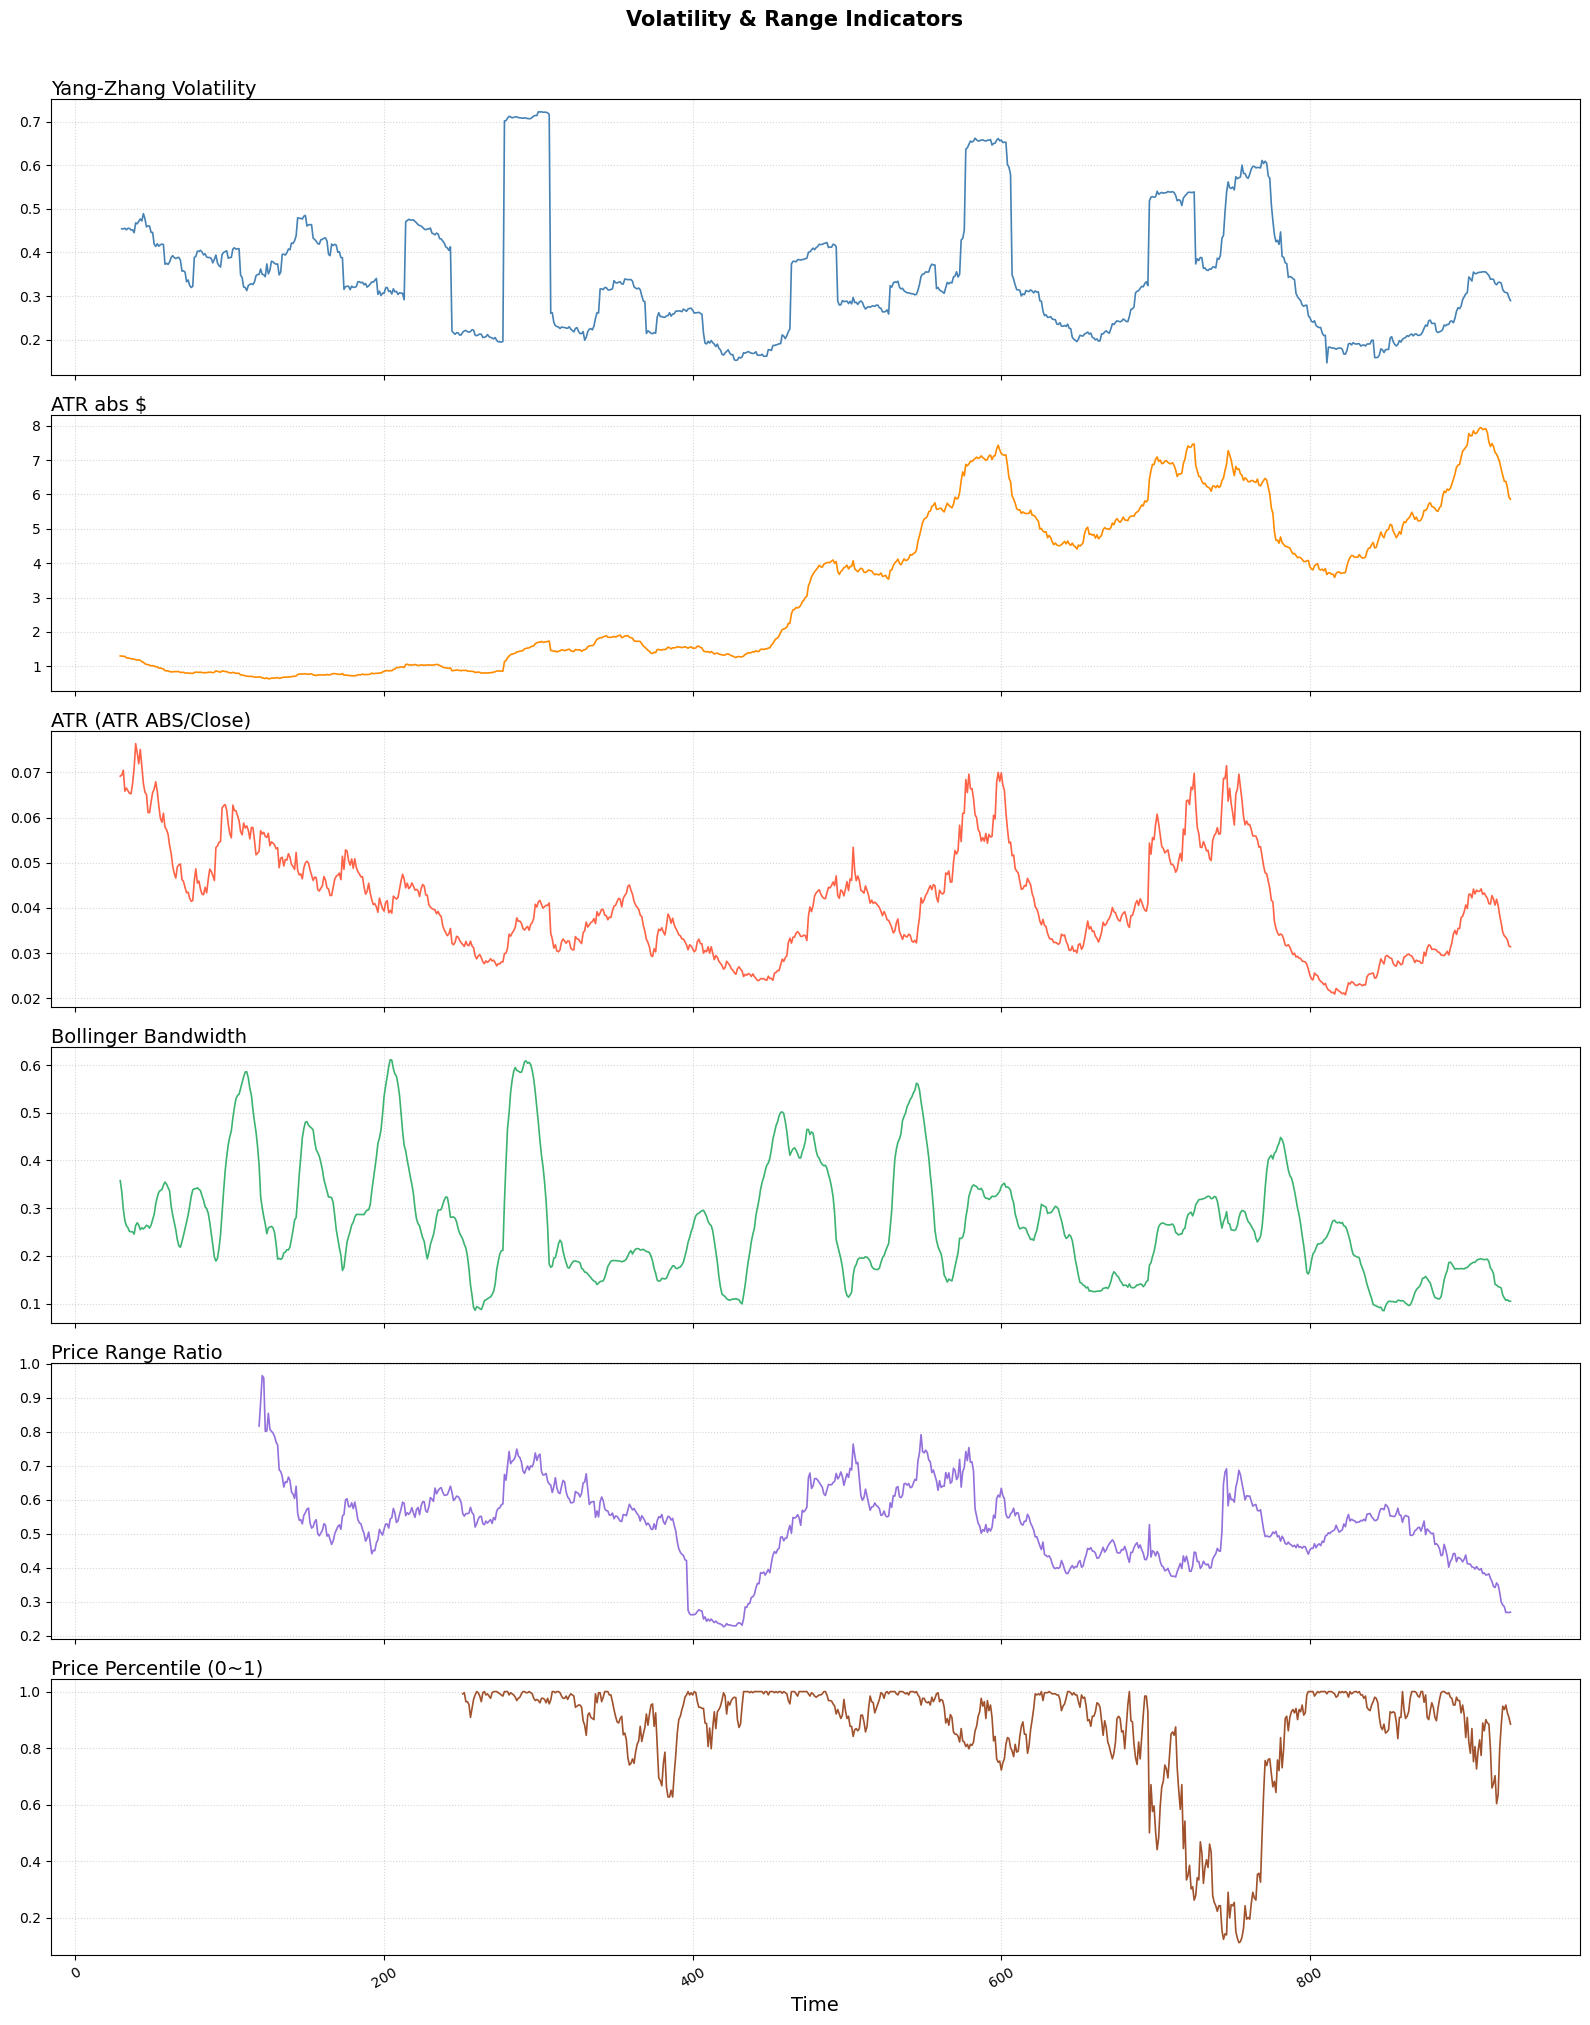

ATR-based grid_step = 0.0377  coverage = 0.3685  max_layers = 9
手动 GRID_STEP = 0.015  MAX_LAYERS = 6（以下回测同时展示两组参数）


In [3]:
from util_Index import volatility_indicators

open_, high, low, close = df['open'], df['high'], df['low'], df['close']
yz, atr_abs, atr_pct, bb, prr, ppercent = volatility_indicators(open_, high, low, close, draw=True)

_coverage   = prr.mean() * 0.7
_fee        = FEE
min_step    = 2 * _fee
_grid_step  = max(float(atr_pct.iloc[-1]) * 1.2, min_step * 2)
_max_layers = int(_coverage / _grid_step)

print(f'ATR-based grid_step = {_grid_step:.4f}  coverage = {_coverage:.4f}  max_layers = {_max_layers}')
print(f'手动 GRID_STEP = {GRID_STEP}  MAX_LAYERS = {MAX_LAYERS}（以下回测同时展示两组参数）')

## 4. 回测引擎

In [4]:
from util_Grid import Strategy_GridTrading
from util_analyze import trades_to_df, plot_ohlc_box_with_volume, plot_equity_cash_position


class Backtester:
    def __init__(self, df, strategy, initial_cash=10000.0, initial_position=0.0,
                 fee=0.0005, startD=None, endD=None, target_size_mode='all_in'):
        self.df_raw           = df.copy()
        self.strategy         = strategy
        df_ind                = self.strategy.prepare_indicators(self.df_raw)
        self.initial_cash     = float(initial_cash)
        self.initial_position = float(initial_position)
        self.fee              = float(fee)
        self.target_size_mode = target_size_mode

        df_ind['date'] = pd.to_datetime(df_ind['date'])
        if startD: df_ind = df_ind[df_ind['date'] >= pd.Timestamp(startD)]
        if endD:   df_ind = df_ind[df_ind['date'] <= pd.Timestamp(endD)]
        self.df = df_ind

    def _init_state(self):
        return {'cash': self.initial_cash, 'position': self.initial_position,
                'avg_price': np.nan, 'entry_price': np.nan,
                'trades': 0, 'fees_paid': 0.0, 'target_size': 0.0}

    def run(self):
        state     = self._init_state()
        trade_log = []
        equity    = np.zeros(len(self.df))
        cash      = np.zeros(len(self.df))
        pos       = np.zeros(len(self.df))

        for i, (idx, row) in enumerate(self.df.iterrows()):
            close = float(row['close'])
            if self.target_size_mode == 'all_in':
                state['target_size'] = state['cash'] / close if close > 0 else 0.0
            else:
                state['target_size'] = 1.0
            self.strategy.on_bar(i, row['date'], row, state, fee=self.fee, trade_log=trade_log)
            equity[i] = state['cash'] + state['position'] * close
            cash[i]   = state['cash']
            pos[i]    = state['position']

        out = pd.DataFrame({'equity': equity, 'cash': cash, 'position': pos,
                            'close': self.df['close'].values}, index=self.df.index)
        out.attrs['final_state'] = state
        return out, trade_log

    @staticmethod
    def stats(equity, periods_per_year=252):
        eq     = equity.dropna()
        ret    = eq.pct_change().fillna(0.0)
        dd     = eq / eq.cummax() - 1.0
        total  = float(eq.iloc[-1] / eq.iloc[0])
        years  = (len(eq) - 1) / periods_per_year
        cagr   = total ** (1 / years) - 1 if years > 0 else np.nan
        vol    = ret.std(ddof=0)
        sharpe = (ret.mean() / vol) * np.sqrt(periods_per_year) if vol > 0 else np.nan
        maxdd  = float(dd.min())
        calmar = (cagr / abs(maxdd)) if maxdd < 0 else np.nan
        return {'CAGR': float(cagr), 'Sharpe': float(sharpe),
                'MaxDD': float(maxdd), 'Calmar': float(calmar)}

print('Backtester 定义完成')

Backtester 定义完成


## 5. 回测 A — 手动参数

In [5]:
strat_A = Strategy_GridTrading(
    center_n        = CENTER_N,
    grid_step       = GRID_STEP,
    max_layers      = MAX_LAYERS,
    stop_pct        = STOP_PCT,
    maxPositionDays = MAX_POS_DAYS,
)

bt_A      = Backtester(df, strat_A, initial_cash=INIT_CASH, fee=FEE)
res_A, trades_A = bt_A.run()

stats_A = Backtester.stats(res_A['equity'])
final_A = res_A.attrs['final_state']
print('=== 回测 A（手动参数）===')
print(f'CAGR:   {stats_A["CAGR"]:.2%}')
print(f'Sharpe: {stats_A["Sharpe"]:.2f}')
print(f'MaxDD:  {stats_A["MaxDD"]:.2%}')
print(f'Calmar: {stats_A["Calmar"]:.2f}')
print(f'Trades: {final_A["trades"]}  Fees: ${final_A["fees_paid"]:.2f}')
print(f'Final Equity: ${res_A["equity"].iloc[-1]:,.2f}  (起始 ${INIT_CASH:,})')

[Reset Grid]: 1st time, anchor=18.4785
max layer: 2022-05-24 00:00:00 ---
[Hard stop] 2022-06-13 00:00:00, new anchor = 17.761000000000003
max layer: 2022-06-14 00:00:00 ---
[Hard stop] 2022-07-01 00:00:00, new anchor = 16.6985
[Reset Grid]: 2022-08-01 00:00:00 position <= floor position
=== 回测 A（手动参数）===
CAGR:   1.11%
Sharpe: 0.16
MaxDD:  -18.87%
Calmar: 0.06
Trades: 24  Fees: $100.17
Final Equity: $52,080.11  (起始 $50,000)


## 6. 回测 B — ATR 自动参数

In [6]:
strat_B = Strategy_GridTrading(
    center_n        = CENTER_N,
    grid_step       = _grid_step,
    max_layers      = _max_layers,
    stop_pct        = STOP_PCT,
    maxPositionDays = MAX_POS_DAYS,
)

bt_B      = Backtester(df, strat_B, initial_cash=INIT_CASH, fee=FEE)
res_B, trades_B = bt_B.run()

stats_B = Backtester.stats(res_B['equity'])
final_B = res_B.attrs['final_state']
print('=== 回测 B（ATR自动参数）===')
print(f'grid_step={_grid_step:.4f}  max_layers={_max_layers}')
print(f'CAGR:   {stats_B["CAGR"]:.2%}')
print(f'Sharpe: {stats_B["Sharpe"]:.2f}')
print(f'MaxDD:  {stats_B["MaxDD"]:.2%}')
print(f'Calmar: {stats_B["Calmar"]:.2f}')
print(f'Trades: {final_B["trades"]}  Fees: ${final_B["fees_paid"]:.2f}')
print(f'Final Equity: ${res_B["equity"].iloc[-1]:,.2f}  (起始 ${INIT_CASH:,})')

[Reset Grid]: 1st time, anchor=18.4785
max layer: 2022-05-24 00:00:00 ---
[Hard stop] 2022-06-13 00:00:00, new anchor = 17.761000000000003
max layer: 2022-06-16 00:00:00 ---
[Hard stop] 2022-07-01 00:00:00, new anchor = 16.6985
[Reset Grid]: 2022-08-01 00:00:00 position <= floor position
=== 回测 B（ATR自动参数）===
grid_step=0.0377  max_layers=9
CAGR:   0.84%
Sharpe: 0.14
MaxDD:  -18.86%
Calmar: 0.04
Trades: 30  Fees: $96.45
Final Equity: $51,561.89  (起始 $50,000)


## 7. 净值对比：A vs B vs Buy-and-Hold

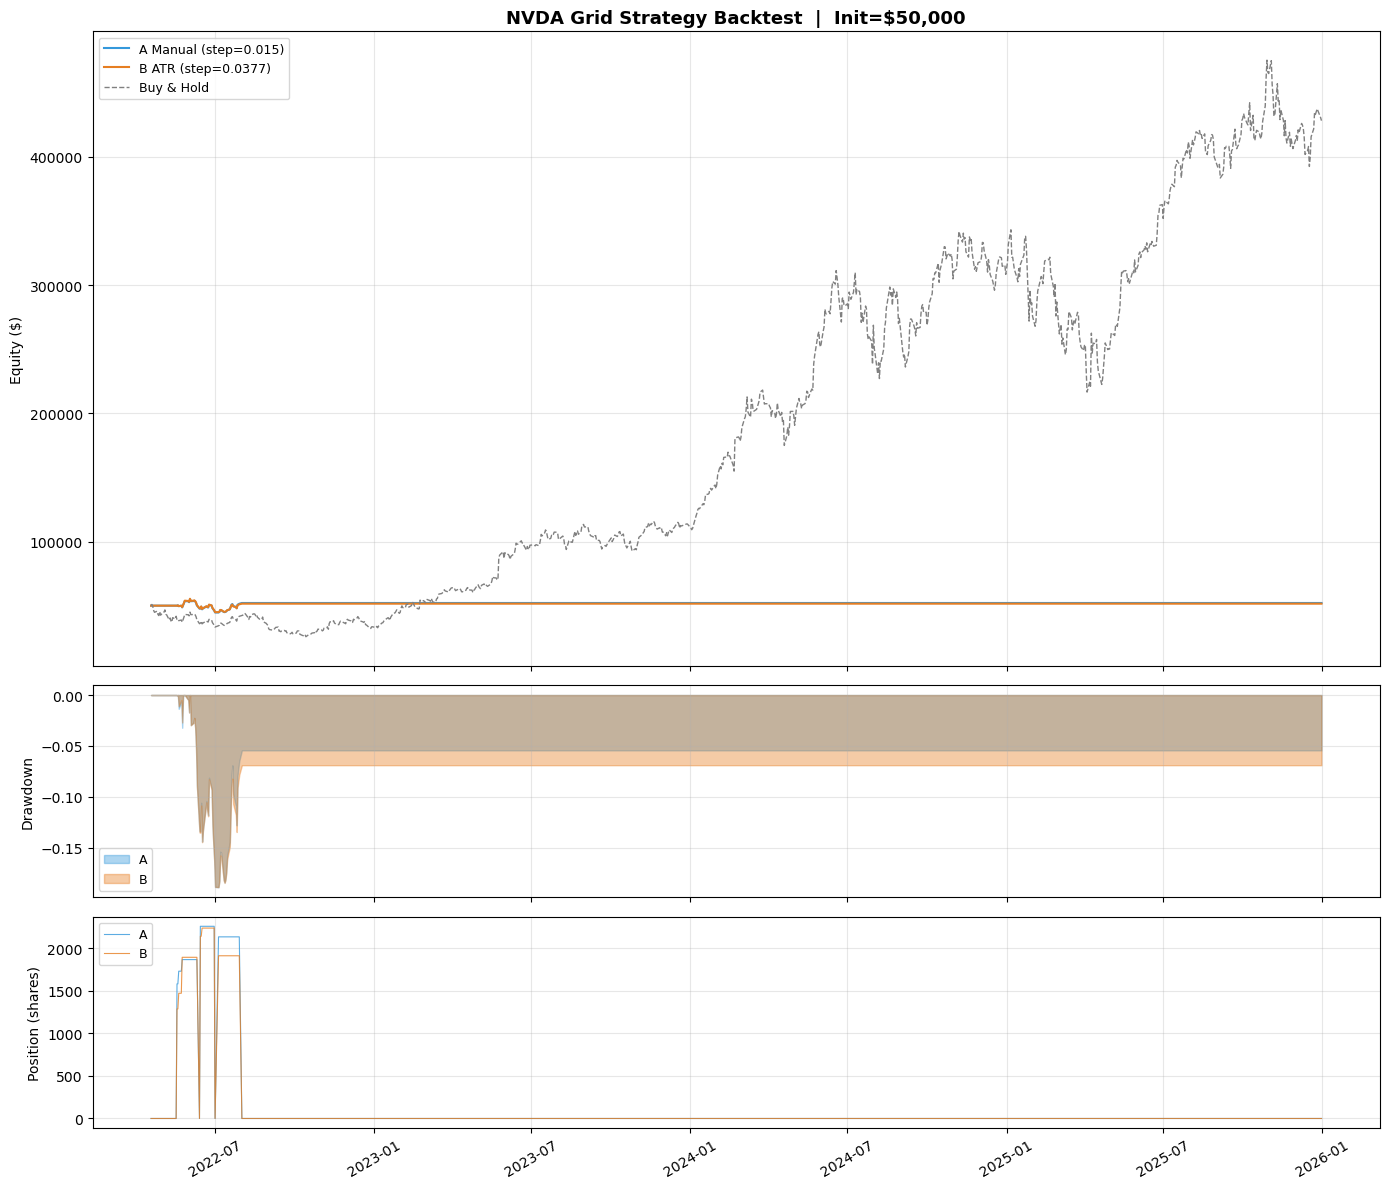

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates = pd.to_datetime(df['date'])

# Buy-and-Hold 基准
bh_equity = INIT_CASH * (df['close'] / df['close'].iloc[0])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# ── Panel 1: Equity ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(dates, res_A['equity'],  label=f'A Manual (step={GRID_STEP})',  color='#3498DB', lw=1.5)
ax.plot(dates, res_B['equity'],  label=f'B ATR (step={_grid_step:.4f})',color='#E67E22', lw=1.5)
ax.plot(dates, bh_equity,         label='Buy & Hold',                     color='gray',    lw=1, ls='--')
ax.set_ylabel('Equity ($)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title(f'{SYMBOL} Grid Strategy Backtest  |  Init=${INIT_CASH:,}', fontsize=13, fontweight='bold')

# ── Panel 2: Drawdown ────────────────────────────────────────────────
for res, color, label in [(res_A, '#3498DB', 'A'), (res_B, '#E67E22', 'B')]:
    eq = res['equity']
    dd = eq / eq.cummax() - 1
    axes[1].fill_between(dates, dd, 0, alpha=0.4, color=color, label=label)
axes[1].set_ylabel('Drawdown')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Panel 3: Position ────────────────────────────────────────────────
axes[2].plot(dates, res_A['position'], color='#3498DB', lw=0.8, alpha=0.8, label='A')
axes[2].plot(dates, res_B['position'], color='#E67E22', lw=0.8, alpha=0.8, label='B')
axes[2].set_ylabel('Position (shares)')
axes[2].legend(loc='upper left', fontsize=9)
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'backtest_grid_{SYMBOL}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. K 线 + 交易点（回测 A）

14 9.06
14 9.06
15 9.06
15 9.06
15 9.06
15 9.06
15 9.06
16 9.06
16 9.06
16 9.06
16 9.06
16 9.06
17 9.06
17 9.06
17 9.06
17 9.06
17 9.06
18 9.06
18 9.06
18 9.06
18 9.06
18 9.06
19 9.06
19 9.06
19 9.06
19 9.06
19 9.06
20 9.06
20 9.06
20 9.06
20 9.06
20 9.06
21 9.06
21 9.06
21 9.06
21 9.06
21 9.06
22 9.06
22 9.06
22 9.06
22 9.06
22 9.06
23 9.06
23 9.06
23 9.06
23 9.06
23 9.06
24 9.06
24 9.06
24 9.06
24 9.06
24 9.06
25 9.06
25 9.06
25 9.06
25 9.06
25 9.06
26 9.06
26 9.06
26 9.06
26 9.06
26 9.06
27 9.06
27 9.06
27 9.06
27 9.06
27 9.06
28 9.06
28 9.06
28 9.06
28 9.06
28 9.06
29 9.06
29 9.06
29 9.06
29 9.06
29 9.06
30 9.06
30 9.06
30 9.06
30 9.06
30 9.06
31 9.06
31 9.06
31 9.06
31 9.06
31 9.06
32 9.06
32 9.06
32 9.06
32 9.06
32 9.06
33 9.06
33 9.06
33 9.06
33 9.06
33 9.06
34 9.06
34 9.06
34 9.06
34 9.06
34 9.06
35 9.06
35 9.06
35 9.06
35 9.06
35 9.06
36 9.06
36 9.06
36 9.06
36 9.06
36 9.06
37 9.06
37 9.06
37 9.06
37 9.06
37 9.06
38 9.06
38 9.06
38 9.06
38 9.06
38 9.06
39 9.06
39 9.06
39 9.06


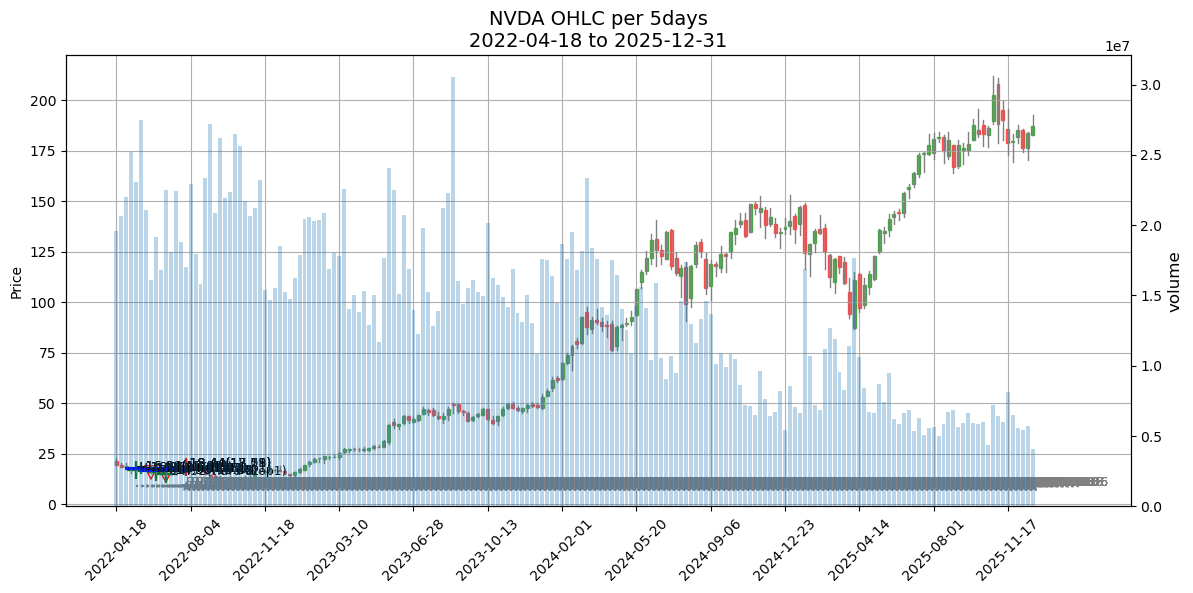

In [8]:
start_str = str(df['date'].iloc[0].date())
end_str   = str(df['date'].iloc[-1].date())

plot_ohlc_box_with_volume(df, SYMBOL,
                          start=start_str, end=end_str,
                          time_period=5, trade_log=trades_A)

## 9. 净值 / Cash / 仓位明细（回测 A）

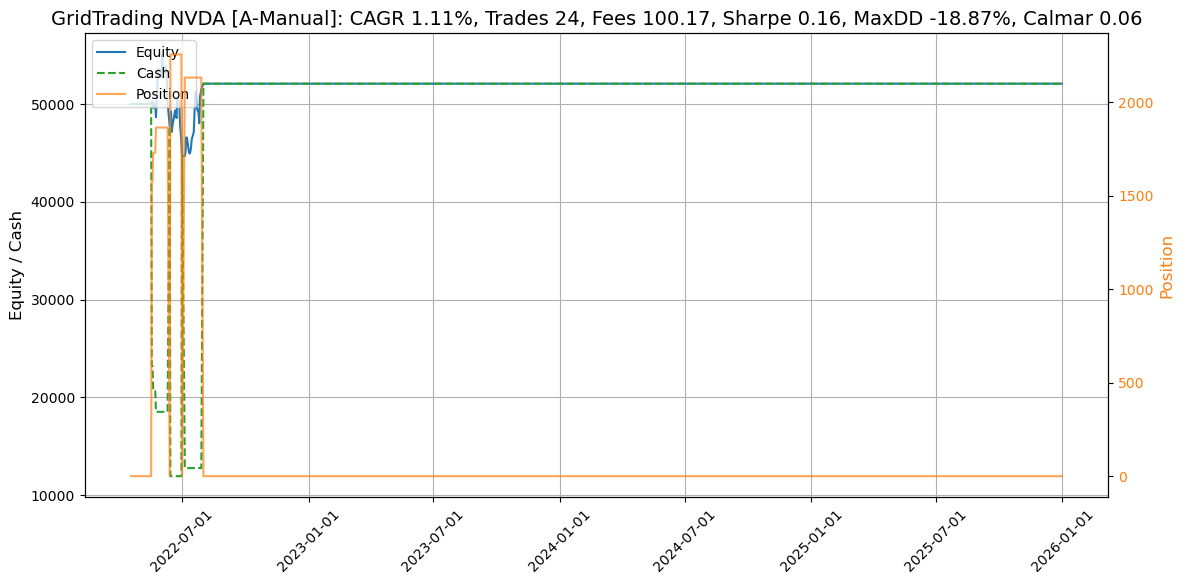

In [9]:
plot_equity_cash_position(res_A, stats_A, final_A, df['date'],
                          strategyName=f'GridTrading {SYMBOL} [A-Manual]')

## 10. 交易记录

In [10]:
trades_df_A = trades_to_df(trades_A,
    csv_file=f'trade_log_grid_{SYMBOL}_A.csv', savelog=True)
print(f'回测 A：共 {len(trades_df_A)} 笔交易')
trades_df_A.tail(20)

trade_log_grid_NVDA_A.csv  saved
回测 A：共 885 笔交易


,time,trade_time,anchor,type,layer,price,size,fee,next_buy,next_sell,position_after,notional
865,2025-12-03,999,9.06,[RESET ANCHOR],0,179.59,0.0,0.0,8.9241,9.1959,0.0,0.0
866,2025-12-04,999,9.06,[RESET ANCHOR],0,183.38,0.0,0.0,8.9241,9.1959,0.0,0.0
867,2025-12-05,999,9.06,[RESET ANCHOR],0,182.41,0.0,0.0,8.9241,9.1959,0.0,0.0
868,2025-12-08,999,9.06,[RESET ANCHOR],0,185.55,0.0,0.0,8.9241,9.1959,0.0,0.0
869,2025-12-09,999,9.06,[RESET ANCHOR],0,184.97,0.0,0.0,8.9241,9.1959,0.0,0.0
870,2025-12-10,999,9.06,[RESET ANCHOR],0,183.78,0.0,0.0,8.9241,9.1959,0.0,0.0
871,2025-12-11,999,9.06,[RESET ANCHOR],0,180.93,0.0,0.0,8.9241,9.1959,0.0,0.0
872,2025-12-12,999,9.06,[RESET ANCHOR],0,175.02,0.0,0.0,8.9241,9.1959,0.0,0.0
873,2025-12-15,999,9.06,[RESET ANCHOR],0,176.29,0.0,0.0,8.9241,9.1959,0.0,0.0
874,2025-12-16,999,9.06,[RESET ANCHOR],0,177.72,0.0,0.0,8.9241,9.1959,0.0,0.0


## 11. 统计汇总

In [11]:
bh_years  = (df['date'].iloc[-1] - df['date'].iloc[0]).days / 365
bh_total  = float(df['close'].iloc[-1] / df['close'].iloc[0])
bh_cagr   = bh_total ** (1 / bh_years) - 1

summary = pd.DataFrame({
    'Strategy':    ['A: Manual Grid', 'B: ATR Grid', 'Buy & Hold'],
    'CAGR':        [f'{stats_A["CAGR"]:.2%}', f'{stats_B["CAGR"]:.2%}', f'{bh_cagr:.2%}'],
    'Sharpe':      [f'{stats_A["Sharpe"]:.2f}', f'{stats_B["Sharpe"]:.2f}', '-'],
    'MaxDD':       [f'{stats_A["MaxDD"]:.2%}', f'{stats_B["MaxDD"]:.2%}', '-'],
    'Calmar':      [f'{stats_A["Calmar"]:.2f}', f'{stats_B["Calmar"]:.2f}', '-'],
    'Trades':      [final_A["trades"], final_B["trades"], 1],
    'Fees ($)':    [f'{final_A["fees_paid"]:.2f}', f'{final_B["fees_paid"]:.2f}', '-'],
    'Final ($)':   [f'{res_A["equity"].iloc[-1]:,.0f}',
                    f'{res_B["equity"].iloc[-1]:,.0f}',
                    f'{bh_equity.iloc[-1]:,.0f}'],
})
print(summary.to_string(index=False))
summary

      Strategy   CAGR Sharpe   MaxDD Calmar  Trades Fees ($) Final ($)
A: Manual Grid  1.11%   0.16 -18.87%   0.06      24   100.17    52,080
   B: ATR Grid  0.84%   0.14 -18.86%   0.04      30    96.45    51,562
    Buy & Hold 78.48%      -       -      -       1        -   428,145


,Strategy,CAGR,Sharpe,MaxDD,Calmar,Trades,Fees ($),Final ($)
0,A: Manual Grid,1.11%,0.16,-18.87%,0.06,24,100.17,"52,080"
1,B: ATR Grid,0.84%,0.14,-18.86%,0.04,30,96.45,"51,562"
2,Buy & Hold,78.48%,-,-,-,1,-,"428,145"
